# Vocabulary Level Prediction — RoBERTa comparison

Fine-tune `roberta-base` on **one consensus target** (`target_vocab` = mean of raters, same as `Model_selection`). Development split on filtered train; final fit on **full** train; evaluation on **test** (same metrics/plots as §6 there). **Weighted MSE** on train matches rare-class emphasis from classical CV.

## 0. Environment

All imports for this notebook live in the **first code cell** below (`torch`, `transformers`, `optuna`, project modules, etc.). Use `importlib.reload` on `utils`, `modeling_utils`, `transformers_utils` after editing `.py` files (same pattern as [Model_selection.ipynb](Model_selection.ipynb)).

In [ ]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments
from transformers.trainer_utils import BestRun

import modeling_utils
import transformers_utils
import utils
import optuna

importlib.reload(utils)
importlib.reload(modeling_utils)
importlib.reload(transformers_utils)

from modeling_utils import (
    filter_by_rater_agreement,
    create_consensus_target,
    build_text_target_dataset,
    build_stratification_bins,
    evaluate_fold,
    round_and_clip_predictions,
    plot_ordinal_predicted_vs_true_scatter,
    plot_ordinal_continuous_boxplot_by_true_class,
    plot_row_normalized_confusion_matrix_from_labels,
)
from transformers_utils import (
    WeightedRegressionTrainer,
    build_compute_objective_fn,
    build_hf_regression_compute_metrics_fn,
    build_model_init_fn,
    build_optuna_hp_space_fn,
    build_tokenized_regression_dataset,
    build_weighted_regression_data_collator,
    get_completed_optuna_trial_count,
    prepare_balanced_regression_weights,
    suppress_hf_loading_report,
)

pd.set_option("display.max_colwidth", None)

## 1. Load data

`Data/train.csv`, `Data/test.csv` (same 80/20 split as EDA).

In [5]:
df_train_raw = pd.read_csv("train.csv")
df_test_raw = pd.read_csv("test.csv")
print(f"Train rows: {len(df_train_raw)}  |  Test rows: {len(df_test_raw)}")

Train rows: 7112  |  Test rows: 1778


## 2. Preprocessing

**Train:** agreement filter + consensus `target_vocab` (same as model selection).  
**Test:** no agreement filter; consensus label for evaluation only (deployment-like).

### 2.1 Train: filter and consensus target

In [6]:
df_train = filter_by_rater_agreement(df_train_raw.copy())
df_train = create_consensus_target(df_train)
df_train_text = build_text_target_dataset(df_train)

### 2.2 Test: consensus label only (no row drops)

In [7]:
df_test_eval = create_consensus_target(df_test_raw.copy())
df_test_text = build_text_target_dataset(df_test_eval)

## 3. Targets and stratification bins

Single scalar target `y`; bins for **stratified** train/val split only (`merge_below=2` aligned with `Model_selection`).

In [8]:
RANDOM_STATE = 42
VAL_FRACTION = 0.15

text_train_all = df_train_text["Text_cleaned"].reset_index(drop=True)
y_train_all = np.asarray(df_train_text["target_vocab"].values, dtype=float)
stratification_bins = build_stratification_bins(y_train_all.astype(int), merge_below=2)

## 4. Train / validation split (development)

**Decision:** 15% held out for early stopping / metric tracking; stratified on merged bins. **No test rows** used here.

In [9]:
row_indices = np.arange(len(text_train_all))
idx_train, idx_val = train_test_split(
    row_indices,
    test_size=VAL_FRACTION,
    random_state=RANDOM_STATE,
    stratify=stratification_bins,
)

text_tr = text_train_all.iloc[idx_train].tolist()
text_val = text_train_all.iloc[idx_val].tolist()
y_tr = y_train_all[idx_train]
y_val = y_train_all[idx_val]

sample_weight_tr = prepare_balanced_regression_weights(y_tr.astype(int))
# Validation loss: uniform weights (interpretable MSE); collator still requires the column.
sample_weight_val = np.ones(len(idx_val), dtype=np.float64)

print(f"Train (dev): {len(text_tr)}  |  Val: {len(text_val)}")

Train (dev): 5783  |  Val: 1021


## 5. Model and tokenizer configuration

**Decision:** `roberta-base`, `AutoModelForSequenceClassification` with `num_labels=1`, `problem_type="regression"`. **Max length** capped for memory; increase if GPU allows.

Loading from `roberta-base`: **MLM head** weights (`lm_head.*`) are unused for sequence classification (often reported as *unexpected*); the **classification head** is task-specific and starts **newly initialized** (*missing* in the LM checkpoint). That is expected before fine-tuning.

In [10]:
MODEL_NAME = "roberta-base"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device: cuda


### 5.1 Tokenized datasets

HF ``datasets`` built in ``transformers_utils.build_tokenized_regression_dataset`` (same pattern as other notebooks: logic in utils, notebook calls only).

In [11]:
ds_train_dev = build_tokenized_regression_dataset(
    tokenizer, text_tr, y_tr, sample_weight_tr, MAX_LENGTH
)
ds_val = build_tokenized_regression_dataset(
    tokenizer, text_val, y_val, sample_weight_val, MAX_LENGTH
)

Map:   0%|          | 0/5783 [00:00<?, ? examples/s]

Map:   0%|          | 0/1021 [00:00<?, ? examples/s]

## 6. Phase A — Fine-tune on train (dev split)

**Decision:** `WeightedRegressionTrainer` + balanced train weights; monitor **QWK** on val (same definition as `evaluate_fold`). Stop / pick best by val QWK.

In [12]:
with suppress_hf_loading_report():
    model_dev = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        problem_type="regression",
    )

training_args_dev = TrainingArguments(
    output_dir="./roberta_dev_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="qwk",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    report_to="none",
    # Keep labels + sample_weight for WeightedRegressionTrainer collator (default would drop non-forward keys).
    remove_unused_columns=False,
)

data_collator = build_weighted_regression_data_collator(tokenizer)
compute_metrics = build_hf_regression_compute_metrics_fn(min_score=0, max_score=5)

trainer_dev = WeightedRegressionTrainer(
    model=model_dev,
    args=training_args_dev,
    train_dataset=ds_train_dev,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_dev.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

The following layers were not sharded: roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.intermediate.dense.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.output.dense.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.output.dense.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.output.dense.bias, roberta.encoder.layer.*.attention.self.key.weight, roberta.embeddings.position_embeddings.weight, roberta.embeddings.LayerNorm.weight, classifier.dense.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.attention.self.value.bias, classifier.out_proj.bias, classifier.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.w

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Qwk,Rmse,Mae
1,0.562722,0.458960,0.426683,0.677466,0.522636
2,0.386665,0.400434,0.579193,0.632799,0.496106
3,0.389057,0.452431,0.546320,0.672630,0.530290


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2169, training_loss=0.5422295024725852, metrics={'train_runtime': 396.3183, 'train_samples_per_second': 43.775, 'train_steps_per_second': 5.473, 'total_flos': 2282336357359104.0, 'train_loss': 0.5422295024725852, 'epoch': 3.0})

## 7. Hyperparameter search (Optuna)

**Decision:** narrow search around the baseline defaults; 15 trials, maximise **val QWK**. Helpers live in `transformers_utils` — notebook calls only.

**Checkpoint / resume:** study is persisted to a local SQLite database (`optuna_roberta.db`). If Colab disconnects, re-running this cell resumes from the last completed trial instead of restarting from scratch.

**Pruning:** `MedianPruner` stops unpromising trials early after each evaluation epoch (Trainer already calls `trial.report` / `trial.should_prune` when `eval_strategy="epoch"`).

In [13]:
N_TRIALS = 15
STUDY_NAME = "roberta_vocab_level"
OPTUNA_STORAGE = "sqlite:///optuna_roberta.db"

# Resume support: skip trials already persisted in the SQLite database.
completed_trials = get_completed_optuna_trial_count(OPTUNA_STORAGE, STUDY_NAME)
remaining_trials = max(0, N_TRIALS - completed_trials)

if completed_trials > 0:
    print(f"Resuming: {completed_trials} / {N_TRIALS} trials already done, {remaining_trials} remaining.")
else:
    print(f"Starting fresh: {N_TRIALS} trials.")

model_init = build_model_init_fn(MODEL_NAME, n_trials=N_TRIALS, suppress_load_report=True)
optuna_hp_space = build_optuna_hp_space_fn()
compute_objective = build_compute_objective_fn(metric_key="eval_qwk")

if remaining_trials > 0:
    # Trainer for HP search: model=None, model_init rebuilds a fresh model each trial.
    trainer_search = WeightedRegressionTrainer(
        model=None,
        model_init=model_init,
        args=training_args_dev,
        train_dataset=ds_train_dev,
        eval_dataset=ds_val,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    best_trial = trainer_search.hyperparameter_search(
        direction="maximize",
        backend="optuna",
        hp_space=optuna_hp_space,
        n_trials=remaining_trials,
        compute_objective=compute_objective,
        # kwargs forwarded to optuna.create_study for checkpoint / resume / pruning.
        storage=OPTUNA_STORAGE,
        study_name=STUDY_NAME,
        load_if_exists=True,
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
    )
else:
    # All trials already done — load the study and reconstruct the BestRun.
    study = optuna.load_study(study_name=STUDY_NAME, storage=OPTUNA_STORAGE)
    bt = study.best_trial
    best_trial = BestRun(str(bt.number), bt.value, bt.params)

print(f"\nBest val QWK: {best_trial.objective:.4f}")
print(f"Best hyperparameters: {best_trial.hyperparameters}")

Starting fresh: 15 trials.


The following layers were not sharded: roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.intermediate.dense.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.output.dense.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.output.dense.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.output.dense.bias, roberta.encoder.layer.*.attention.self.key.weight, roberta.embeddings.position_embeddings.weight, roberta.embeddings.LayerNorm.weight, classifier.dense.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.attention.self.value.bias, classifier.out_proj.bias, classifier.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.w

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[I 2026-03-22 16:35:16,607] A new study created in RDB with name: roberta_vocab_level



  Trial 1 / 15


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Qwk,Rmse,Mae
1,0.602942,0.385033,0.491345,0.620510,0.505828
2,0.370977,0.467984,0.540315,0.684094,0.543887


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-03-22 17:27:30,461] Trial 14 pruned. 



Best val QWK: 0.5595
Best hyperparameters: {'learning_rate': 2.278447843853074e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 16, 'weight_decay': 0.05163077578272495, 'warmup_ratio': 0.013004216324544154}


## 8. Phase B — Refit on full train (best hparams)

**Decision:** use winning hyperparameters from §7; train on **full** filtered train (no val holdout). This is the final model.

In [14]:
sample_weight_full = prepare_balanced_regression_weights(y_train_all.astype(int))
text_full = text_train_all.tolist()
ds_train_full = build_tokenized_regression_dataset(
    tokenizer, text_full, y_train_all, sample_weight_full, MAX_LENGTH
)

with suppress_hf_loading_report():
    model_full = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        problem_type="regression",
    )

# Start from best trial hparams; override fixed args that don't come from the search.
best_hp = best_trial.hyperparameters
training_args_full = TrainingArguments(
    output_dir="./roberta_full_output",
    learning_rate=best_hp["learning_rate"],
    per_device_train_batch_size=best_hp["per_device_train_batch_size"],
    num_train_epochs=best_hp["num_train_epochs"],
    weight_decay=best_hp["weight_decay"],
    warmup_ratio=best_hp["warmup_ratio"],
    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=50,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
)

trainer_full = WeightedRegressionTrainer(
    model=model_full,
    args=training_args_full,
    train_dataset=ds_train_full,
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer_full.train()

Map:   0%|          | 0/6804 [00:00<?, ? examples/s]

The following layers were not sharded: roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.intermediate.dense.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.output.dense.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.output.dense.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.output.dense.bias, roberta.encoder.layer.*.attention.self.key.weight, roberta.embeddings.position_embeddings.weight, roberta.embeddings.LayerNorm.weight, classifier.dense.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.attention.self.value.bias, classifier.out_proj.bias, classifier.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.w

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
50,3.874325
100,0.926782
150,0.807589
200,0.750031
250,0.650786
300,0.887013
350,0.634802
400,0.725069
450,0.584283
500,0.502861


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1704, training_loss=0.5839322184173155, metrics={'train_runtime': 448.0292, 'train_samples_per_second': 60.746, 'train_steps_per_second': 3.803, 'total_flos': 3580383094235136.0, 'train_loss': 0.5839322184173155, 'epoch': 4.0})

## 9. Test-set evaluation

**Protocol:** `trainer_full` fit on full train only (best hparams from §7); test = **predict** + `evaluate_fold` + same ordinal plots as `Model_selection` §6. **No** test leakage.

### 9.1 Predict on test

In [ ]:
text_test = df_test_text["Text_cleaned"].reset_index(drop=True).tolist()
y_test = np.asarray(df_test_text["target_vocab"].values, dtype=int)
weights_test_dummy = np.ones(len(text_test), dtype=np.float32)

ds_test = build_tokenized_regression_dataset(
    tokenizer, text_test, y_test.astype(float), weights_test_dummy, MAX_LENGTH
)

pred_out = trainer_full.predict(ds_test)
y_pred_test = np.asarray(pred_out.predictions, dtype=float).squeeze()

### 9.2 Metrics (QWK, RMSE, MAE)

In [16]:
test_metrics = evaluate_fold(y_test, y_pred_test, min_score=0, max_score=5)
summary_test = (
    pd.DataFrame([test_metrics], index=["Test set (RoBERTa, tuned)"])
    .rename(columns={"qwk": "QWK", "rmse": "RMSE", "mae": "MAE"})
)
display(summary_test)

,QWK,RMSE,MAE
"Test set (RoBERTa, tuned)",0.553769,0.714232,0.555969


### 9.3 Diagnostic plots 

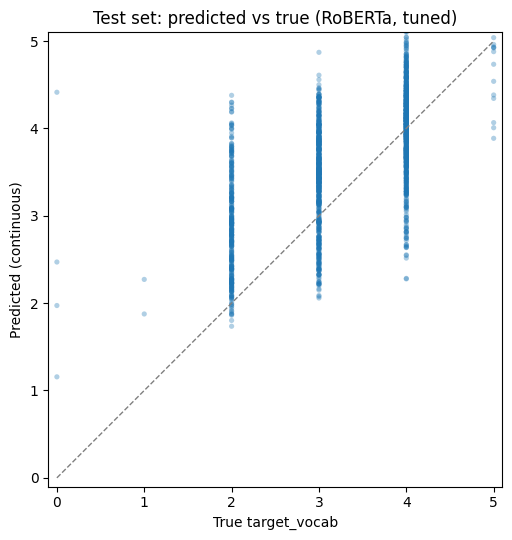

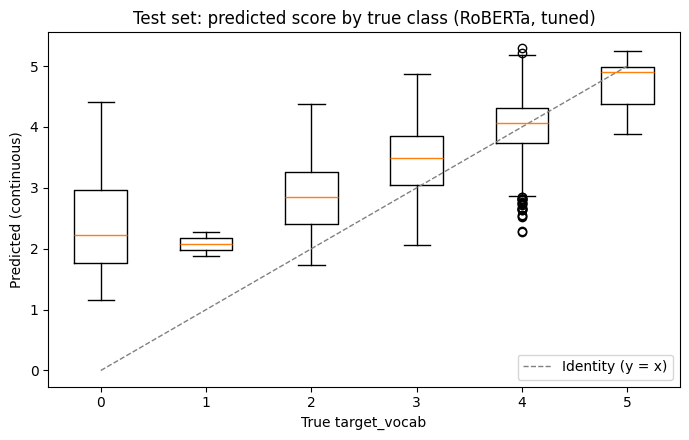

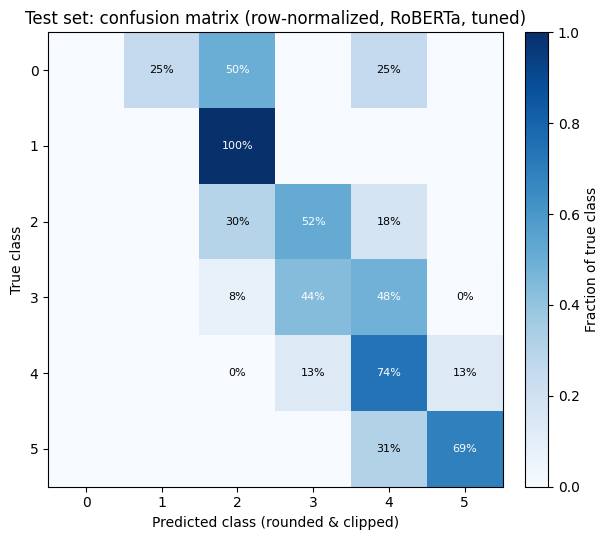

In [17]:
fig_scatter = plot_ordinal_predicted_vs_true_scatter(
    y_test,
    y_pred_test,
    title="Test set: predicted vs true (RoBERTa, tuned)",
    xlabel="True target_vocab",
)
plt.show()

fig_box = plot_ordinal_continuous_boxplot_by_true_class(
    y_test,
    y_pred_test,
    title="Test set: predicted score by true class (RoBERTa, tuned)",
    xlabel="True target_vocab",
)
plt.show()

y_pred_ord = round_and_clip_predictions(y_pred_test, 0, 5)
ordinal_labels = np.arange(0, 6)
fig_cm = plot_row_normalized_confusion_matrix_from_labels(
    y_test,
    y_pred_ord,
    labels=ordinal_labels,
    title="Test set: confusion matrix (row-normalized, RoBERTa, tuned)",
    xlabel="Predicted class (rounded & clipped)",
)
plt.show()